In [66]:
## Import Libraries
import numpy as np
import matplotlib.pyplot as plt

## System Parameters
L=1 # Rod length
alpha=1.65e-4 # Thermal Diffusivity
delx=0.01 # Element length
deltt=0.01 # Time step
T=10 # Simulation time

## Space Discretization
X=np.linspace(0,1,101) 
print(type(X))

## Initial Condition
Temperature_initial=100*np.sin(X)
temp_curr=Temperature_initial
temp_next=np.array([])
Temperature=[]

<class 'numpy.ndarray'>


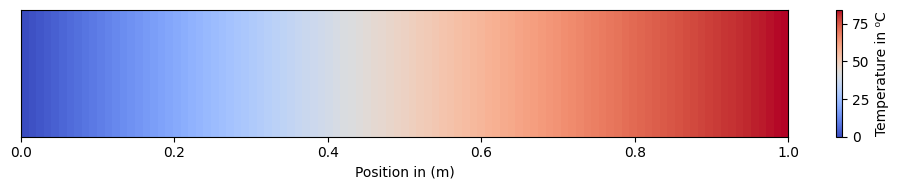

In [67]:
## plot initial_condition
fig,ax=plt.subplots(figsize=(10,2))
extent=[0,1,0,0.5]
img=ax.imshow(Temperature_initial[np.newaxis,:],cmap="coolwarm",aspect="auto",extent=extent)
plt.xlabel("Position in (m)")
plt.yticks([])
plt.colorbar(img,ax=ax,label="Temperature in ⁰C")
plt.tight_layout()
plt.savefig("Initial_Condition.png")

In [ ]:
## Solve the equation by Central Difference Method
for t in range(0,int(T/deltt),1):
    for i in range(1,-1):
        tem_nxt=temp_curr[i] + (deltt/delx**2) * (temp_curr[i-1]- 2*temp_curr[i] + temp_curr[i+1]) ## temperature
        temp_next=np.append(temp_next,tem_nxt)

    #print(temp_next)
    temp_curr=temp_next
    Temperature.append(temp_curr)


In [ ]:
## create Animation
import matplotlib.animation as animation
print(type(Temperature[0]))

fig,ax=plt.subplots(figsize=(10,2))
extent=[0,1,0,0.5]
img=ax.imshow(Temperature_initial[np.newaxis,:],cmap="coolwarm",aspect="auto",extent=extent)
plt.xlabel("Position in (m)")
plt.colorbar(img,ax=ax,label="Temperature in ⁰C")
plt.tight_layout()

def animate(i):
    a=Temperature[i]
    print(a)
    img.set_data(a)
    return [img]

anim=animation.FuncAnimation(fig,animate,frames=range(0,int(T/deltt)))
writer=animation.FFMpegWriter(fps=60)
anim.save("1D_Heat_Equation.mp4",writer=writer)
